In [1]:
#import os, time
import numpy as np
import pandas as pd
from itertools import product

from pathlib import Path
from matplotlib import pyplot as plt
#import matplotlib.patches as mpatches
#from matplotlib.lines import Line2D

import seaborn as sns

In [2]:
def strrs(p, oe, ce, ss, alloc='equal'):

    UA = 1 - ce
    TP = p * (1 - oe) # true positives on target class
    if TP > UA:
        return 

    # here we calcuilate the size of stratum 1, taking CE and OE into account
    W_1 = TP / UA
    
    # the inverse is our stratum 2
    W_2 = 1 - W_1

    # calculate the proportions within stratum 1 
    p_hat_1 = p * (1 - oe) / W_1
    p_hat_2 = (p - W_1 * p_hat_1) / W_2  # we invert W_1*p_1 + W_2*p_2 = p_hat

    S_1 = p_hat_1 * (1-p_hat_1)
    S_2 = p_hat_2 * (1-p_hat_2)
                    
    if alloc == 'equal':
        n_1 = ss/2
        n_2 = ss/2
        
    if alloc == 'proportional':
        n_1 = W_1 * ss
        n_2 = W_2 * ss
        
    if alloc == 'optimal':
        n_1 = int(((np.sqrt(S_1)*W_1)/((np.sqrt(S_1)*W_1) + (np.sqrt(S_2)*W_2))) * ss)
        n_2 = int(ss - n_1)

    if alloc == 'balanced':
        #print(ss / 2, W_1 * ss)
        n_1 = (ss / 2 + W_1 * ss) / 2
        n_2 = int(ss - n_1)

    # calculate ses
    se_1 = np.sqrt(W_1**2 * S_1 / (n_1 - 1))
    se_2 = np.sqrt(W_2**2 * S_2 / (n_2 - 1))

    se_srs = np.sqrt(p * (1-p)/(ss-1))
    se_strrs = np.sqrt(se_1**2 + se_2**2)
    
    re = (se_srs**2) / (se_strrs**2) # THIS????
    
    assert np.round(W_1*p_hat_1 + W_2*p_hat_2, 7) == p
    
    results =  pd.DataFrame([p, se_strrs, se_srs, re, ss, alloc, oe, ce]).T
    results.columns = ['p', 'se strrs', 'se srs', 'Relative Efficiency', 'Sample Size', 'Allocation Scheme', 'Omission Error', 'Comission Error']
    return results

In [12]:
sample_dict = {
    'fractions_of_actual_change': [0.02, 0.003, 0.001],
    'omission_errors': [i/100 for i in range(5, 51, 5)],
    'comission_errors': [i/100 for i in range(5, 99, 10)],
    'sample_sizes': [5000],
    'allocation_scheme': ['equal', 'proportional', 'balanced']
}

dfs = []
for p_hat, oe, ce, ss, alloc in list(product(*sample_dict.values())):
    #print(p_hat, oe, ce, ss, alloc)
    dfs.append(strrs(p_hat, oe, ce, ss, alloc))

final = pd.concat(dfs)

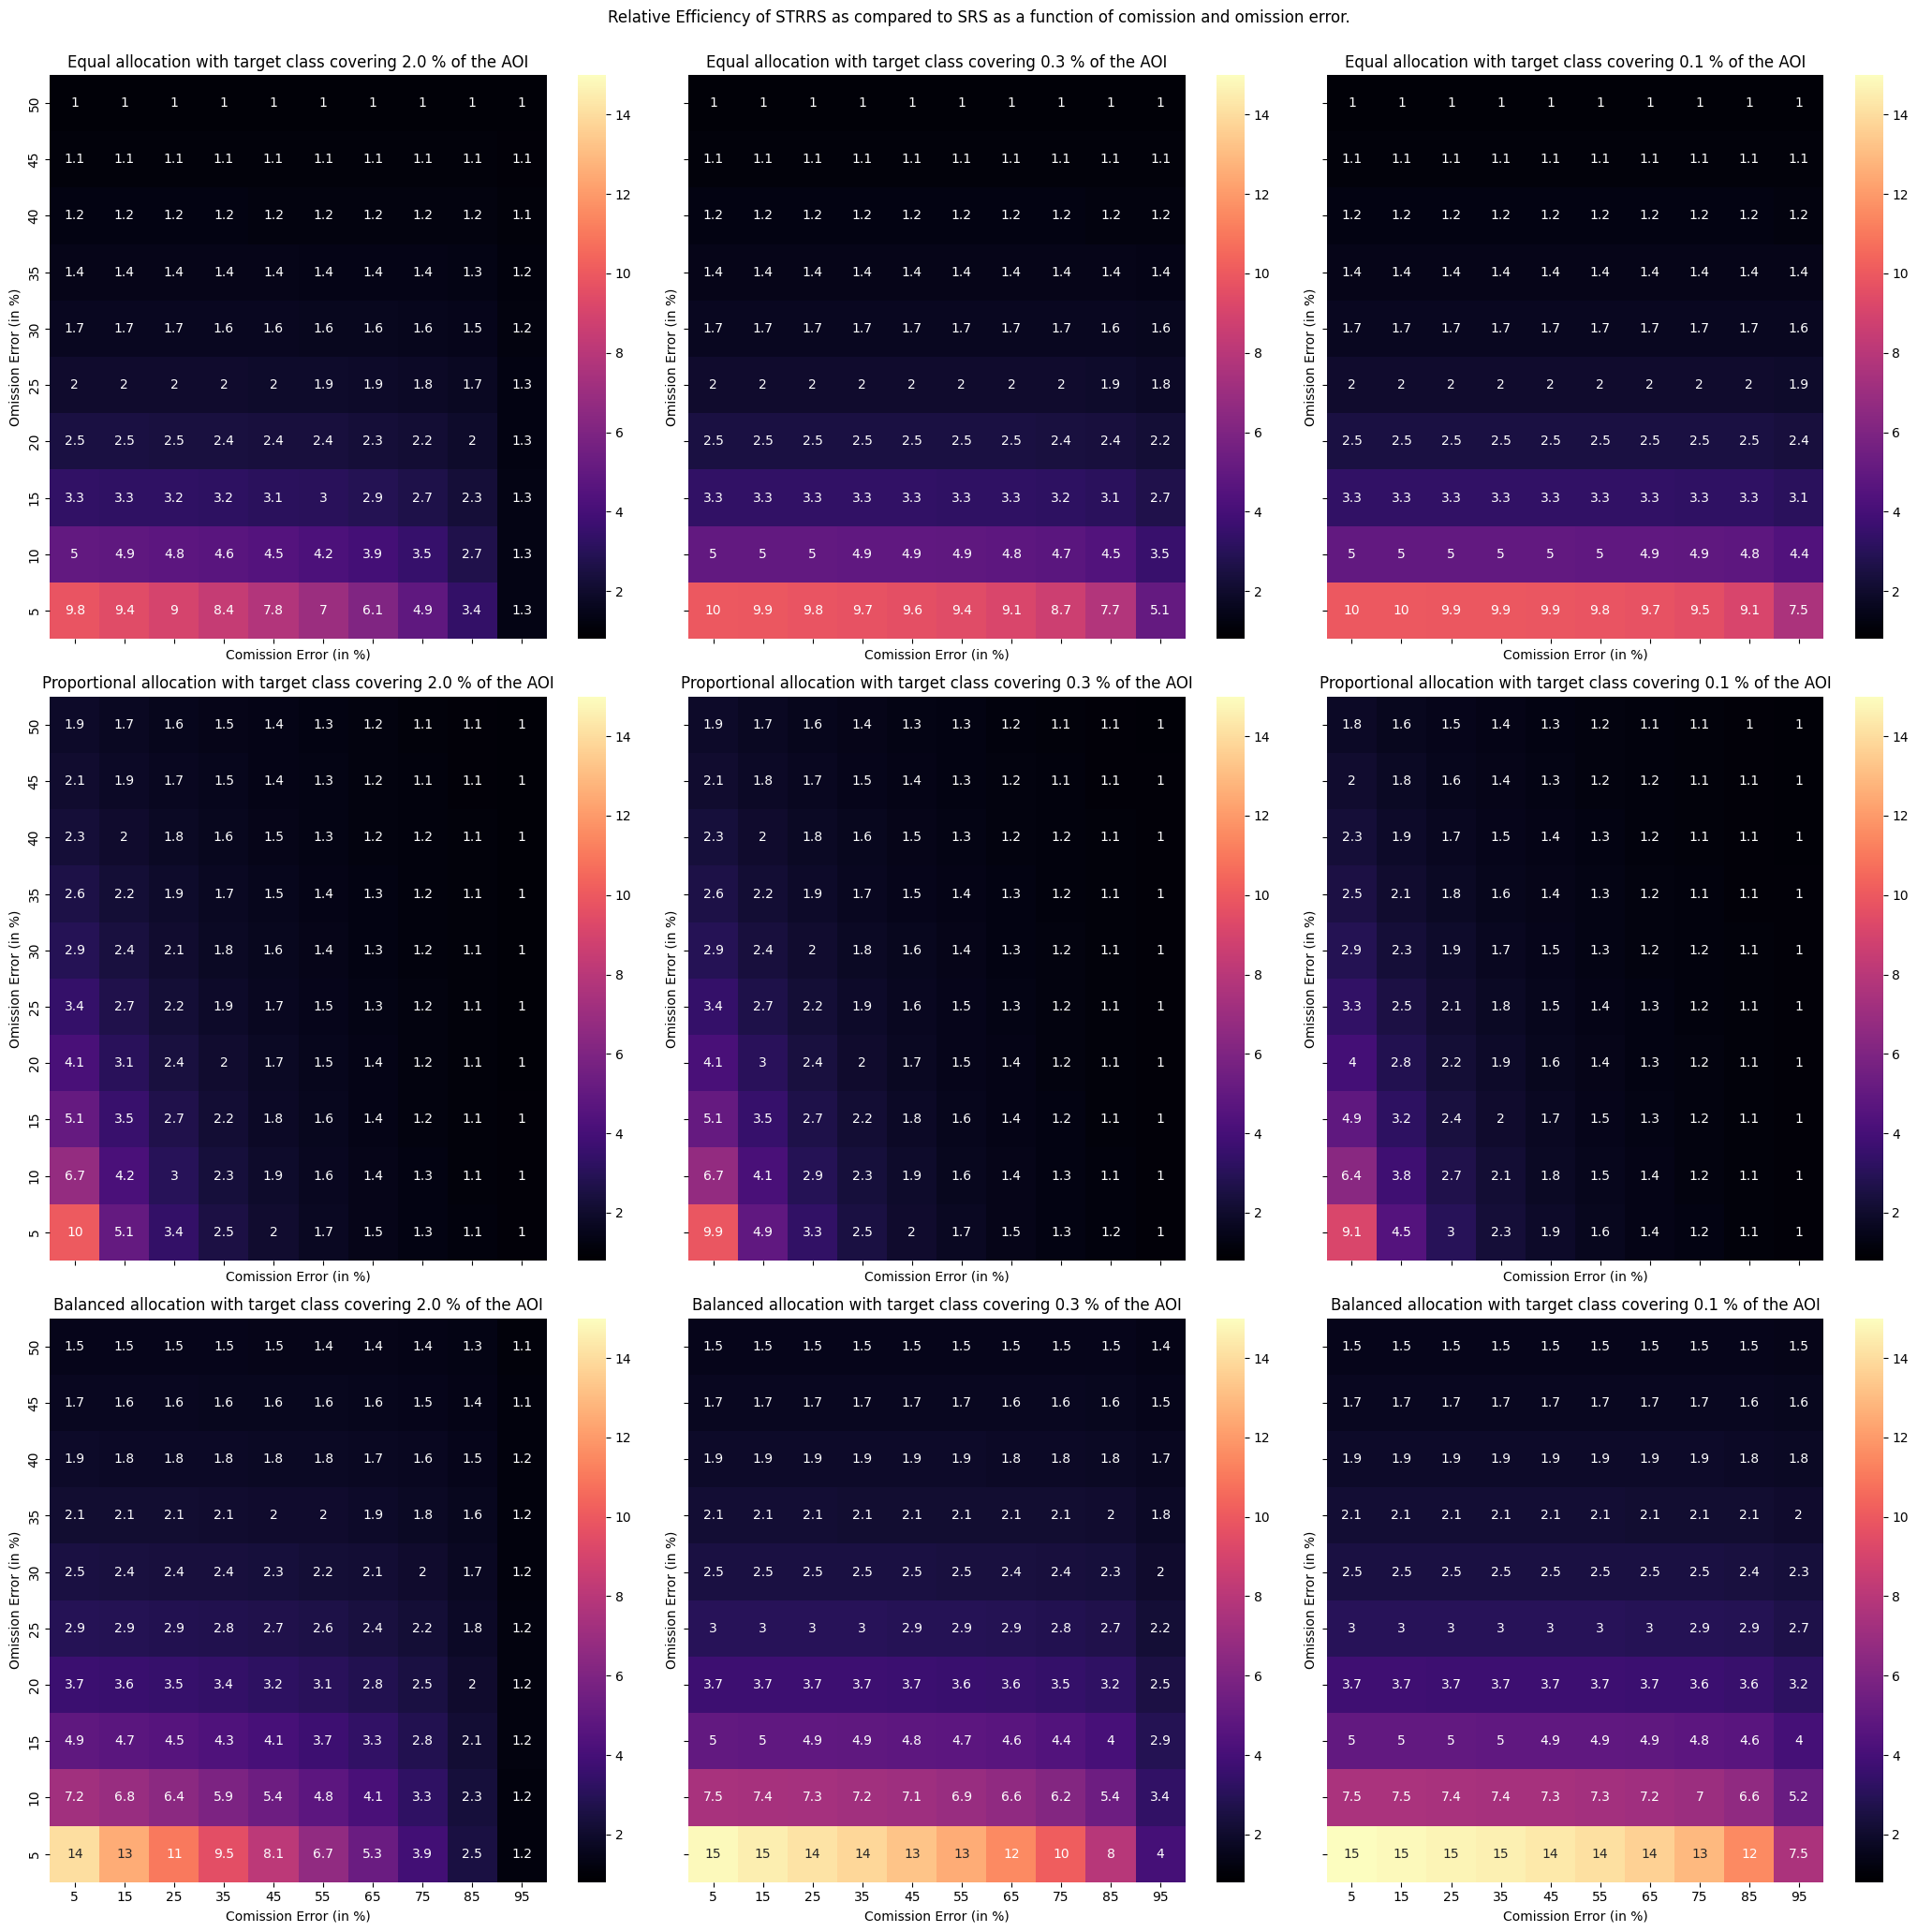

In [13]:
def plot_heat(ax, alloc, p):

    heat = final[
        (final['Allocation Scheme'] == alloc) &
        #(final['Sample Size'] == 3000) &
        (final['p'] == p) 
    ].copy()

    heat.loc[:, 'Omission Error (in %)'] = (heat["Omission Error"] * 100).astype('int')
    heat.loc[:, 'Comission Error (in %)'] = (heat["Comission Error"] * 100).astype('int')
    heat_grouped = heat.pivot(index="Omission Error (in %)", columns="Comission Error (in %)", values="Relative Efficiency")
    heat_grouped = heat_grouped[heat_grouped.columns].astype(float).sort_values('Omission Error (in %)', ascending=False)
    ax = sns.heatmap(heat_grouped, cmap='magma', annot=True, ax=ax, vmin=0.8, vmax=15)
    ax.set_title(f'{alloc.capitalize()} allocation with target class covering {p*100} % of the AOI')

fig, ax = plt.subplots(3, 3, figsize=(21, 21), sharex=True, sharey=True)
for idx, iters in enumerate(list(product(
    sample_dict['allocation_scheme'], 
    sample_dict['fractions_of_actual_change']))
):
    #print(idx, iters)
    alloc, p_hat = iters
    ax = ax.flatten()
    ax[idx] = plot_heat(ax[idx], alloc, p_hat)

#plt.suptitle('Relative Efficiency of STRRS as compared to SRS as a function of proportion and sample allocation.\n\n')
plt.suptitle('Relative Efficiency of STRRS as compared to SRS as a function of comission and omission error.\n\n')
plt.tight_layout()
plt.show()